# Estimation and Confidence Intervals
**Dr. Dave Wanik - University of Connecticut**

--------------------------------------------------------------------------
This notebook considers several important aspects of sampling. We begin by
studying point estimates. A **point estimate** is a single value (point) derived from a sample and used to estimate a population value. For example, suppose we select a sample of 50 executives and ask how many hours they worked last week. Compute the mean of this sample of 50 and use the value of the sample mean as a point estimate of the unknown population mean. However, a point estimate is a single value. A more informative approach is to present a *range of values* in which
we expect the population parameter to occur. Such a *range of values* is called a **confidence interval**.

Frequently in business we need to determine the appropriate size of a sample.
* How many voters should a polling organization contact to forecast the election outcome?
* How many products do we need to examine to ensure our quality level?

This notebook also develops a strategy for determining the appropriate number of observations in the sample.

# Point Estimate for a Population Mean

A **point estimate** is a single statistic used to estimate a population parameter. Suppose Best Buy Inc. wants to estimate the mean age of people who purchase HD televisions. They select a random sample of 50 recent purchases, determine the age of each buyer, and compute the mean age of the buyers in the sample. The
mean of this sample is a point estimate of the population mean.

So, a **point estimate** is a statistic, computed from sample information that estimates
the population parameter.

Let's do a mock-up of this example.

In [1]:
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Generate a random sample of 50 observations from a normal distribution
my_sample = np.random.normal(loc=55, scale=10, size=50)
print(my_sample)


[59.96714153 53.61735699 61.47688538 70.23029856 52.65846625 52.65863043
 70.79212816 62.67434729 50.30525614 60.42560044 50.36582307 50.34270246
 57.41962272 35.86719755 37.75082167 49.37712471 44.8716888  58.14247333
 45.91975924 40.87696299 69.65648769 52.742237   55.67528205 40.75251814
 49.55617275 56.1092259  43.49006423 58.75698018 48.9936131  52.0830625
 48.98293388 73.52278185 54.86502775 44.42289071 63.22544912 42.7915635
 57.08863595 35.40329876 41.71813951 56.96861236 62.3846658  56.71368281
 53.84351718 51.98896304 40.2147801  47.80155792 50.39361229 65.57122226
 58.4361829  37.36959845]


In [2]:
# we can calculate the mean of this sample - it's our point estimate
np.mean(my_sample)

# and look, our point estimate is kind of close to the population mean(55, defined above)
# but it's not perfect... we should strive to quantify this

52.745260947438595

There's nothing *wrong* with a point estimate - it's just that you don't have to be so penalizing. Why not add some confidence/uncertainty around your point estimate?

And BTW - it's totally a rad party trick to pull out the next time you're at work - don't just rely on the point estimate! Give some confidence around your estimate.

# Confidence Intervals for a Population Mean
A **point estimate**, however, tells only part of the story... While we expect the point estimate to be close to the population parameter, we would like to measure how close it really is.

A **confidence interval** serves this purpose. For example, we estimate the mean annual income for construction workers in the New York area is \$85,000. The range of this estimate might be from \$81,000 to \$89,000. We can describe how confident we are that the population parameter is in the interval by making a *probability statement* like:

<center>"We are 90 percent sure that the mean annual income of construction workers in the New York area is between $81,000 and \$89,000."</center>

A **confidence interval** (CI) is a range of values constructed from sample data so that
the population parameter is likely to occur within that range at a *specified
probability*. The specified probability is called the *level of confidence*.

To compute a confidence interval, we will consider two situations:
* We use sample data to estimate $\mu$ with $\bar{X}$ and the population standard deviation ($\sigma$) is **known**.
* We use sample data to estimate $\mu$ with $\bar{X}$, and the population standard deviation is **unknown**. In this case, we substitute the sample standard deviation ($s$)
for the population standard deviation($\sigma$).

^ ***See?*** Our point estimate is still really important - but now you're either going to use the population standard deviation or use the sample standard deviation (and we'll give ourselves a penalty shot for doing this).

There are important distinctions in the assumptions between these two situations. We first consider the case where is known.

#Confidence Intervals for a Population Mean: Population Standard Deviation ($\sigma$) **Known**

A confidence interval is computed using two statistics: the sample mean, $\bar{X}$ (which is your point estimate!), and
the standard deviation.

From previous chapters, you know that the standard deviation is an important statistic because it measures the dispersion, or width, of a population or sample distribution. In computing a confidence interval, the standard deviation is directly used to compute the range of the confidence interval.

**Say this three times slowly aloud:** "A confidence interval is just a function of the center and spread of the sample. If I know these two values, I can construct a confidence interval (no problem)."

To demonstrate the idea of a confidence interval, we start with one simplifying
assumption. That assumption is that we know the value of the population standard
deviation, $\sigma$. Knowing  allows us to simplify the development of a confidence interval because we can use the standard normal distribution (mean of 0 and standard deviation of 1).

Recall that the sampling distribution of the sample mean is the distribution of all sample means, $\bar{X}$, of sample size n from a population. The population standard
deviation, $\sigma$, is known. From this information, and the central limit theorem, we know
that the sampling distribution follows the normal probability distribution with a mean
of $\mu$ and a standard deviation $\sigma/\sqrt{n}$. Also recall that this value ($\sigma/\sqrt{n}$) is called the **standard error**.

## General Confidence Interval Statements using z-statistics
The results of the central limit theorem allow us to make the following general
confidence interval statements using z-statistics:
1. Ninety-five percent of the sample means selected from a population will be
within **1.96** standard errors of the population mean $\mu$.
2. Ninety-nine percent of the sample means will lie within **2.58** standard errors of
the population mean.

These confidence interval statements provide examples of levels of confidence and
are called a 95 percent confidence interval and a 99 percent confidence interval. The 95 percent and 99 percent are the levels of confidence and refer to the
percentage of similarly constructed intervals that would include the parameter being
estimated—in this case, $\mu$.

And remind yourself, **a standard error IS NOT the same thing as a standard deviation**. A standard error is a scaled version of the standard deviation (by the square root of the sample size, $n$!). More specifically, the standard error of the
mean reports the variation in the distribution of sample means. It is really the standard
deviation of the distribution of sample means.

**Burn those two numbers into your brain:** 1.96 and 2.58. Where do they come from?

In [3]:
from scipy.stats import norm

# Set seed for reproducibility
np.random.seed(42)

# hello norm!

# lower tail
# 'return the value of the distribution where 2.5% of the data lies below this point'
lower_tail = norm.ppf(0.025, loc=0, scale=1)
print(lower_tail)

# upper tail
# 'return the value of the distribution where 2.5% of the data lies ABOVE this point'
upper_tail = norm.ppf(0.975, loc=0, scale=1)  # Use 1 - alpha for upper tail
print(upper_tail)

# see the symmetry?


-1.9599639845400545
1.959963984540054


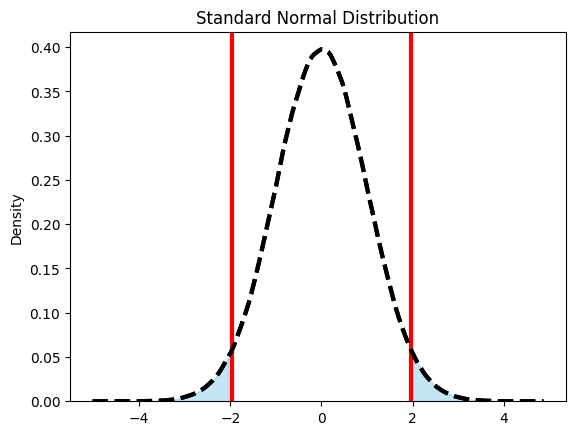

In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

# Set seed for reproducibility
np.random.seed(42)

# Generate random samples from a standard normal distribution
x = np.random.normal(loc=0, scale=1, size=1000000)

# Plot density
sns.kdeplot(x, color='black', linestyle='dashed', linewidth=3)
plt.title('Standard Normal Distribution')

# Add vertical lines for -1.96 and 1.96
plt.axvline(x=-1.96, color='red', linewidth=3)
plt.axvline(x=1.96, color='red', linewidth=3)

# Add shaded polygon to the RIGHT
dens = sns.kdeplot(x, color='black', linestyle='dashed', linewidth=3)
x_values = dens.get_lines()[0].get_xdata()
y_values = dens.get_lines()[0].get_ydata()
x1 = np.min(np.where(x_values >= 1.96))
x2 = np.max(np.where(x_values <= np.inf))
plt.fill_between(x_values[x1:x2], y_values[x1:x2], color='skyblue', alpha=0.5)

# Add shaded polygon to the LEFT
x1 = np.min(np.where(x_values >= -np.inf))
x2 = np.max(np.where(x_values <= -1.96))
plt.fill_between(x_values[x1:x2], y_values[x1:x2], color='skyblue', alpha=0.5)

# Show the plot
plt.show()


Each tail has 2.5% of the probability mass in it! When you add them together, you'll get 5%. That 5% means there's only a 5% chance the sample mean doesn't fall within our confidence interval (it will be some extreme value in the tail). Don't believe me?

In [5]:
from scipy.stats import norm

# Calculate the probability for the left-hand tail
left_tail_prob = norm.cdf(-1.96, loc=0, scale=1)

print(left_tail_prob)


0.024997895148220435


In [ ]:
# of course, you could use the right hand tail
1- norm.cdf(-1.96, loc=0, scale=1)

0.9750021048517795

## Formula for a Confidence Interval
These are the two sets of numbers you need to memorize - 1.96 for a 95% CI, 2.58 for a 99% CI!

For a 95% confidence interval,
<center>$\bar{X} \pm 1.96\frac{\sigma}{\sqrt{n}}$</center>

For a 99% confidence interval,
<center>$\bar{X} \pm 2.58\frac{\sigma}{\sqrt{n}}$</center>

We are not just restricted to 95% and 99% confidence intervals. Here is a generalized formula.
<center>$\bar{X} \pm z\frac{\sigma}{\sqrt{n}}$</center>

where $z$ depends on the level of confidence. You will use `qnorm()` to get your $z$ values (as we did above).

FYI here are some other confidence levels and z-values.

Confidence Level | $z$ value
---|---
80 percent |1.28
94 percent | 1.88
96 percent | 2.05

Don't believe me?

In [10]:
from scipy.stats import norm

# Calculate the values for an 80% confidence interval (10% in each tail)
lower_limit = norm.ppf(0.1, loc=0, scale=1)
upper_limit = norm.ppf(0.9, loc=0, scale=1)

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)


Lower Limit: -1.2815515655446004
Upper Limit: 1.2815515655446004


In [12]:
from scipy.stats import norm

# Calculate the values for a 94% confidence interval (3% in each tail)
lower_limit = norm.ppf(0.03, loc=0, scale=1)
upper_limit = norm.ppf(0.97, loc=0, scale=1)

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)


Lower Limit: -1.880793608151251
Upper Limit: 1.8807936081512509


## Example
The American Management Association wishes to have information on the mean
income of store managers in the retail industry. A random sample of 256 managers
reveals a sample mean of 45,420. The standard deviation of this population is
2,050. The association would like answers to the following questions:
1. What is the population mean?
2. What is a reasonable range of values for the population mean?

<center>$\bar{X} \pm z\frac{\sigma}{\sqrt{n}}$</center>

3. How do we interpret these results?



In [13]:
# 1) for population mean, your best estimate is the sample mean
# which is your point estimate
# so it's just $45,420
Xbar = 45420
Xbar

45420

In [14]:
# 2) 'reasonable range' is code for 'confidence interval'
# you have your general formula

<center>$\bar{X} \pm z\frac{\sigma}{\sqrt{n}}$</center>


In [15]:
from scipy.stats import norm

# Given values
Xbar = 45420  # dollars
n = 256  # managers
sd = 2050  # population standard deviation

# Confidence level
confidence_level = 0.95

# Calculate the z-value for the given confidence level (two-tailed)
z = norm.ppf(1 - (1 - confidence_level) / 2)

print("z-value for a 95% confidence interval:", z)

z-value for a 95% confidence interval: 1.959963984540054


In [16]:
# now solve
z*sd/np.sqrt(n)

251.12038551919443

Hence, $45420 \pm 251$ is a solid range.

How to interpet? Suppose we select many samples of 256
store managers, perhaps several hundred. For each sample, we compute the
mean and then construct a 95 percent confidence interval, such as we did in the
previous section. We could expect about 95 percent of these confidence intervals to contain the *population mean*. About 5 percent of the intervals would not
contain the population mean annual income, which is $\mu$.

# Confidence Intervals for a Population Mean: Population Standard Deviation ($\sigma$) **Unknown**
So that was nice... but really life is MESSY.

You are likely never going to know the population standard deviation - and even if you did - I would say don't use it. Just use the sample standard deviation. Yes, it's a little more penalizing, but better to be more uncertain than overly confident (this will usually cost much more money!)

Instead of using the standard normal distribution (also known as the z distribution) we will introduce the t distribution!

t IS NOT equal to z (when sample size is small)...

To determine a confidence interval for the population mean with an unknown
standard deviation, we use the t-distribution.

Since the population standard deviation is unknown, we use the formula to determine the confidence interval:<br>
<center>$\bar{X}\pm t\frac{S}{\sqrt{n}}$</center>

Where:
* $\bar{X}$ is the sample mean
* $t$ is the critical value (it's a function of the 'degrees of freedom' ($df$) which is $n-1$, where $n$ is the sample size)
* $n$ is the sample size
* $s$ is the sample standard deviation

Let's compare t and z for a sample size of 10 and different levels of confidence.

In [17]:
from scipy.stats import norm

# Confidence levels
confidence_90 = 0.90
confidence_95 = 0.95
confidence_99 = 0.99

# Calculate z-values for the given confidence levels (two-tailed)
z_90 = norm.ppf(1 - (1 - confidence_90) / 2)
z_95 = norm.ppf(1 - (1 - confidence_95) / 2)
z_99 = norm.ppf(1 - (1 - confidence_99) / 2)

print("z-value for a 90% confidence interval:", z_90)
print("z-value for a 95% confidence interval:", z_95)
print("z-value for a 99% confidence interval:", z_99)


z-value for a 90% confidence interval: 1.6448536269514722
z-value for a 95% confidence interval: 1.959963984540054
z-value for a 99% confidence interval: 2.5758293035489004


In [18]:
from scipy.stats import t

# Sample size and degrees of freedom
n = 90
df = n - 1  # Degrees of freedom for a t-distribution

# Confidence levels
confidence_90 = 0.90
confidence_95 = 0.95
confidence_99 = 0.99

# Calculate t-values for the given confidence levels (two-tailed)
t_90 = t.ppf(1 - (1 - confidence_90) / 2, df)
t_95 = t.ppf(1 - (1 - confidence_95) / 2, df)
t_99 = t.ppf(1 - (1 - confidence_99) / 2, df)

print("t-value for a 90% confidence interval:", t_90)
print("t-value for a 95% confidence interval:", t_95)
print("t-value for a 99% confidence interval:", t_99)


t-value for a 90% confidence interval: 1.662155325834565
t-value for a 95% confidence interval: 1.9869786993737677
t-value for a 99% confidence interval: 2.632204189673441


In [20]:
from scipy.stats import t

# Sample size and degrees of freedom
n = 10
df = n - 1  # Degrees of freedom for a t-distribution

# Confidence levels
confidence_90 = 0.90
confidence_95 = 0.95
confidence_99 = 0.99

# Calculate t-values for the given confidence levels (two-tailed)
t_90 = t.ppf(1 - (1 - confidence_90) / 2, df)
t_95 = t.ppf(1 - (1 - confidence_95) / 2, df)
t_99 = t.ppf(1 - (1 - confidence_99) / 2, df)

print("t-value for a 90% confidence interval:", t_90)
print("t-value for a 95% confidence interval:", t_95)
print("t-value for a 99% confidence interval:", t_99)


t-value for a 90% confidence interval: 1.8331129326536335
t-value for a 95% confidence interval: 2.2621571627409915
t-value for a 99% confidence interval: 3.2498355440153697


See how t is always bigger than z?! This is fundamental. For small sample sizes, t > z.

But what about for big sample sizes, like n=100? They converge!

## Example
A tire manufacturer wishes to investigate the tread life of its tires. A sample of 10 tires driven 50,000 miles revealed a sample mean of 0.32 inches of tread remaining with a standard deviation of 0.09 inches.
1. Construct a 95 percent confidence interval for the population mean.
2. Would it be reasonable for the manufacturer to conclude that after 50,000 miles the population mean amount of tread remaining is 0.30 inches?

In [22]:
import numpy as np
from scipy.stats import t

# Given values
Xbar = 0.32  # inches
n = 10  # tires
s = 0.09  # sample standard deviation

# Calculate degrees of freedom
df = n - 1

# Calculate t-value for a 95% confidence interval (two-tailed)
t_value = t.ppf(0.025, df=df)

# Calculate margin of error
margin_of_error = np.abs(t_value * (s / np.sqrt(n)))

# Calculate confidence interval
lower_limit = Xbar - margin_of_error
upper_limit = Xbar + margin_of_error

print(f"95% Confidence Interval: ({round(lower_limit, 3)}, {round(upper_limit, 3)})")


95% Confidence Interval: (0.256, 0.384)


<br>
<center>$\bar{X}\pm t\frac{S}{\sqrt{n}}$</center>


In [23]:
np.abs(t_value * (s / np.sqrt(n)))

0.06438212153573152

Hence $0.32\pm0.064$ is the confidence interval. The endpoints of the confidence interval are 0.256 and 0.384. <br>



How to interpret this? If we repeated this study 200 times, calculating the 95 percent confidence interval with each sample’s mean and the standard deviation, 190 of the intervals would include the population mean. Ten of the intervals would not include the population mean. This is the effect of sampling error.

We can conclude that the population mean is in the interval. The manufacturer can be reasonably sure (95 percent confident) that the mean remaining tread depth is between 0.256 and 0.384 inches. Because the value of 0.30 is in this interval, it is possible that the mean of the population is 0.30.

# Confidence Intervals for a Proportion

Proportion is the fraction, ratio, or percent indicating the part of the sample or the population having a particular trait of interest. <br>

A sample proportion, p,  is found by x, the number of successes, divided by n, the number of observations.<br>
<center> $p = \frac{X}{n}$</center>

<br>The population proportion is identified by $\pi$. To develop a confidence interval for a proportion, we need to meet the following assumptions:<br>
1. The binomial conditions, have been met.
2. The values $n$ and $n(1-\pi)$  should both be greater than or equal to 5.<br>

We construct a confidence interval for a population proportion, with the following formula:

<center> $p\pm z\sqrt{\frac{p(1-p)}{n}}$

## Example
The union representing the Bottle Blowers of America (BBA) is considering a proposal to merge with the Teamsters Union. According to BBA union bylaws, at least three-fourths of the union membership must approve any merger. A random sample of 2,000 current BBA members reveals 1,600 plan to vote for the merger proposal.
1. What is the estimate of the population proportion?
2. Develop a 95 percent confidence interval for the population proportion.
3. Basing your decision on this sample information, can you conclude that the necessary proportion of BBA members favor the
merger? Why?


Calculate the sample proportion using the formula:<br>
<center> $p = \frac{X}{n}$</center>

In [24]:
#1. What is the estimate of the population proportion?
X = 1600
n = 2000
p = X/n
p

0.8

Thus, we estimate that 80 percent of the population favor the merger proposal. We determine the 95 percent confidence interval using formula:<br>
<center> $p\pm z\sqrt{\frac{p(1-p)}{n}}$

In [ ]:
from scipy.stats import norm

# Calculate the Z statistic for a 95% confidence interval (two-tailed)
z_value = norm.ppf(1 - 0.025)  # Since SciPy uses the cumulative distribution function, no need to specify lower.tail=FALSE

print("Z value for a 95% confidence interval:", z_value)


Z value for a 95% confidence interval: 1.959963984540054


In [ ]:
# now solve
z*np.sqrt(p*(1-p)/n)

0.01753045081153163

$0.80\pm0.0175$ The end points of the confidence interval are 0.782 and 0.818. The lower endpoint is greater than 0.75.
Therefore, we conclude that the merger proposal will likely pass because the interval estimate includes values greater than 75 percent of the union membership.

# Choosing an Appropriate Sample Size

There are three factors that determine the sample size when we wish to estimate the population parameter:<br>
1. The margin of error the researcher will tolerate.
2. The level of confidence desired, for example, 95%.
3. The variation or dispersion of the population being studied.

# Sample Size to Estimate a Population Mean (optional)
To estimate a population mean, we can express the interaction among these three
factors and the sample size in the following formula. Notice that this formula is the margin of error used to calculate the endpoints of confidence intervals to estimate a population mean!<br>
<center>$E=z\frac{\sigma}{\sqrt n}$</center><br>


Solving the above equation yields, the formula for Sample Size to Estimate the Population mean which is: <br>
<center>$n = \left(\frac{Z\sigma}{E}\right)^2$ </center><br>

where:<br>
$n$ is the size of the sample.<br>
$z$ is the standard normal value corresponding to the desired level of confidence.<br>
$\sigma$ is the population standard deviation.<br>
$E$ is the maximum allowable error.

##Example
A student in public administration wants to determine the mean amount members of
city councils in large cities earn per month as remuneration for being a council member. The error in estimating the mean is to be less than \$100 with a 95 percent level of confidence. The student found a report by the Department of Labor that reported a standard deviation of \$1,000. What is the required sample size?

In [ ]:
from scipy.stats import norm

# Given values
sigma = 1000
E = 100

# Calculate the Z value
z_value = norm.ppf(1 - 0.025)  # Since SciPy uses the cumulative distribution function, no need to specify lower.tail=FALSE

# Calculate the margin of error
margin_of_error = z_value * (E / sigma)

print("Z value:", z_value)
print("Margin of Error:", margin_of_error)


Z value: 1.959963984540054
Margin of Error: 0.1959963984540054


In [ ]:
# Calculate the sample size (n)
n = ((z_value * sigma) / E) ** 2
print(n)

384.1458820694126


The computed value of 384.16 is rounded up to 385. The result is not always a whole number, the usual practice is to round up any fractional result to the next whole number. A sample of 385 is required
to meet the specifications.  If the student wants to increase the level of confidence, for example to 99 percent, this will require a larger sample.

In [ ]:
from scipy.stats import norm

# Calculate the Z value for a 99% confidence interval (two-tailed)
z_value = norm.ppf(1 - 0.005)  # Since SciPy uses the cumulative distribution function, no need to specify lower.tail=FALSE

print("Z value for a 99% confidence interval:", z_value)

Z value for a 99% confidence interval: 2.5758293035489004


In [ ]:
# now solve
n = ((z_value*sigma)/(E))**2
n

663.4896601021213

Observe how much the change in the confidence level changed the size of the sample. An increase from the 95 percent to the 99 percent level of confidence resulted in an increase of 279 observations or 73%

In [ ]:
(664-385)/385*100

72.46753246753246

This would greatly increase the cost of the study, both in terms of time and money. Hence, the level of confidence should be considered carefully.

# Sample Size to Estimate a Population Proportion (optional)

To determine the sample size for a proportion, the same three variables need to be
specified:
1. The margin of error.
2. The desired level of confidence.
3. The variation or dispersion of the population being studied.

For the binomial distribution, the margin of error is:<br>
<center> E = $z\sqrt{\frac{\pi*(1-\pi)}{n}}$</center><br>

Solving this equation for n yields the following equation for the Sample Size for the Population Proportion:<br>

<center> n=$\pi(1-\pi)(\frac{Z}{E})^2$</center><br>

where:<br>
n is the size of the sample<br>
z is the standard normal value corresponding to the desired level of confidence<br>
$\pi$ is the population proportion<br>
E is the maximum allowable error.


##Example
The study in the previous example also estimates the proportion of cities that
have private refuse collectors. The student wants the margin of error to be within 0.10 of the population proportion, the desired level of confidence is 90%, and no  estimate is available for the population proportion. What is the required sample size?

In [ ]:
from scipy.stats import norm

# Given values
E = 0.10  # Margin of error
z_value = norm.ppf(1 - 0.05)  # Z value for a 90% confidence interval

print("Z value for a 90% confidence interval:", z_value)

# Assuming no estimate of the population proportion is available, use 0.50
Pi = 0.50


Z value for a 90% confidence interval: 1.6448536269514722


In [ ]:
# The number of observations are:
n = (Pi*(1-Pi))*((z_value/E)**2)
n

67.63858635238533

The student needs a random sample of 98 cities.

# Optional: Population Correction Factor
The populations we have sampled so far have been very large or infinite. What if the sampled population is not very large? We need to make some adjustments in the way we compute the standard error of the sample means and the standard error of the sample proportions.

Though not covered here, you can read more about the population correction factor. It shrinks the uncertainty!